Loaded Proposed Method: 249000 total actions
Loaded Domain Randomization: 249000 total actions
Loaded Model-Specific (Random): 249000 total actions


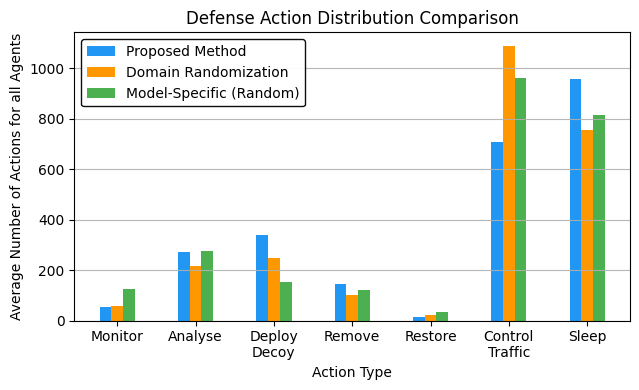

In [27]:
import re
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

def parse_actions_file(filepath):
    """Parse actions.txt and count action types."""
    action_counts = defaultdict(int)
    
    # Action type patterns
    action_patterns = {
        'Monitor': re.compile(r'\[Monitor\]'),
        'Analyse': re.compile(r'\[Analyse'),
        'DeployDecoy': re.compile(r'\[DeployDecoy'),
        'Remove': re.compile(r'\[Remove'),
        'Restore': re.compile(r'\[Restore'),
        'BlockTrafficZone': re.compile(r'\[BlockTrafficZone\]'),
        'AllowTrafficZone': re.compile(r'\[AllowTrafficZone\]'),
        'Sleep': re.compile(r'\[Sleep\]')
    }
    
    with open(filepath, 'r') as f:
        content = f.read()
        
        for action_type, pattern in action_patterns.items():
            count = len(pattern.findall(content))
            action_counts[action_type] = count
    
    # Combine traffic control actions
    action_counts['Control Traffic'] = action_counts.pop('BlockTrafficZone', 0) + \
                                        action_counts.pop('AllowTrafficZone', 0)
    
    return action_counts

# Defense methods to compare
defense_files = {
    "Proposed Method": "actions_ours.txt",
    "Domain Randomization": "actions_DR.txt", 
    "Model-Specific (Random)": "actions_Rand.txt",
    "Sleep Defense": "actions_Sleep.txt",
    "Optimal": "actions_optimal.txt"
}

# Action categories to plot
action_categories_names = ['Monitor', 'Analyse', 'Deploy\nDecoy', 'Remove', 'Restore', 'Control\nTraffic', 'Sleep']
action_categories = ['Monitor', 'Analyse', 'DeployDecoy', 'Remove', 'Restore', 'Control Traffic', 'Sleep']

# Parse all files
all_counts = {}
for label, filename in defense_files.items():
    try:
        counts = parse_actions_file(filename)
        all_counts[label] = counts
        print(f"Loaded {label}: {sum(counts.values())} total actions")
    except FileNotFoundError:
        print(f"WARNING: {filename} not found")

# Prepare data for plotting
methods = list(all_counts.keys())
data_matrix = np.zeros((len(action_categories), len(methods)))

for j, method in enumerate(methods):
    for i, action in enumerate(action_categories):
        data_matrix[i, j] = all_counts[method].get(action, 0)

# Plot grouped bar chart
fig, ax = plt.subplots(figsize=(6.5, 4))
x = np.arange(len(action_categories))
width = 0.15
colors = ['#2196F3', '#FF9800', '#4CAF50', '#F44336', '#9C27B0']

for i, method in enumerate(methods):
    offset = width * (i - len(methods)/2 + 0.5)
    ax.bar(x + offset, data_matrix[:, i]/(100), width, label=method, color=colors[i % len(colors)])

ax.set_xlabel('Action Type')
ax.set_ylabel('Average Number of Actions for all Agents')
ax.set_title('Defense Action Distribution Comparison')
ax.set_xticks(x)
ax.set_xticklabels(action_categories_names, rotation=0, ha='center')
ax.legend()
ax.grid(True, alpha=0.9, axis='y')
plt.savefig("res3.jpg", dpi=180)
leg = plt.legend(edgecolor="black",framealpha=0.95)
leg.get_frame().set_linewidth(1)
plt.tight_layout()
plt.show()


Loaded agents: ['Proposed Method', 'Domain Randomization', 'Model-Specific (Random)']
Proposed Method
Domain Randomization
Model-Specific (Random)


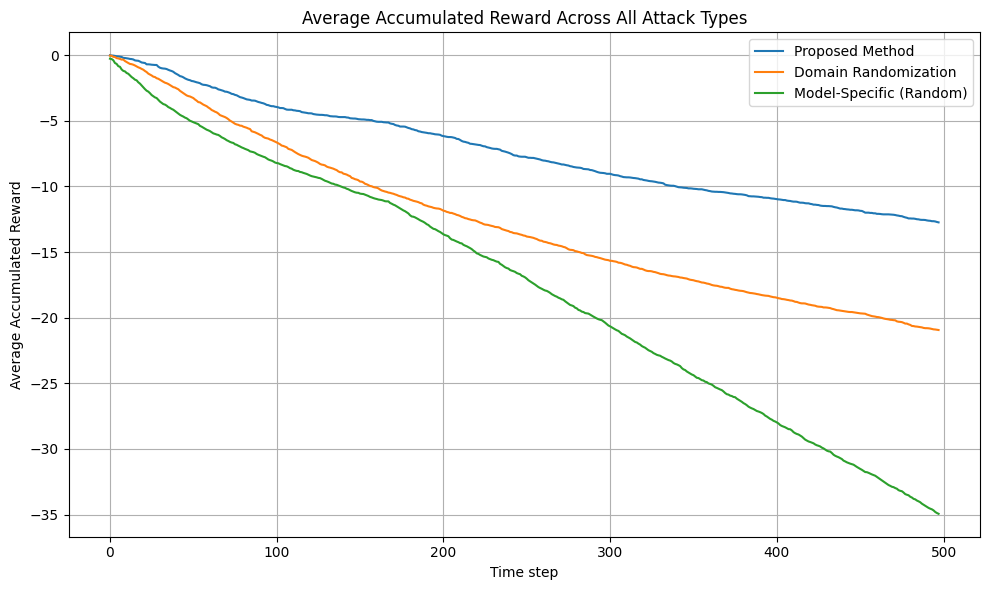

In [43]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = "."   # your main output folder

def load_step_rewards(path):
    """Loads all step reward sequences from a step_rewards.txt file."""
    step_rewards = []
    pattern = re.compile(r"Episode \d+ step_rewards: \[(.*?)\]")

    with open(path, "r") as f:
        for line in f:
            m = pattern.search(line)
            if m:
                rewards = np.fromstring(m.group(1), sep=",")
                step_rewards.append(rewards)

    return np.array(step_rewards)     # shape: (episodes, 500)

BASE_DIR = "." 
def load_all_agents(base_dir):
    """Load all agents (folders) and return dict: {agent_name: step_rewards_array}."""
    agents = {
    "Proposed Method": "step_rewards_ours.txt",
    "Domain Randomization": "step_rewards_DR.txt", 
    "Model-Specific (Random)": "step_rewards_Rand.txt",
    # "Sleep Defense": "step_rewards_Sleep.txt",
    # "Optimal": "step_rewards_optimal.txt"
}

    for agent in agents:
            file_path = os.path.join(agents[agent])
            rewards = load_step_rewards(file_path)
            agents[agent] = rewards

    return agents


def compute_average_per_agent(step_rewards):
    """
    step_rewards: shape (episodes, 500)
    Returns: average cumulative reward curve, shape (500,)
    """
    cumulative = np.cumsum(step_rewards, axis=1)   # convert each episode to cumulative reward
    return cumulative.mean(axis=0)                 # average over episodes (100)

# -----------------------------------------------------
# MAIN
# -----------------------------------------------------
names = ["Proposed Method", "Domain Randomization", "Model-Specific (Random)"]

agents = load_all_agents(BASE_DIR)
print("Loaded agents:", list(agents.keys()))

# compute per-agent accumulated average curve
agent_avg_curves = {}
for agent, rewards in agents.items():
    agent_avg_curves[agent] = compute_average_per_agent(rewards)

# -----------------------------------------------------
# Average *across* attack types
# -----------------------------------------------------
plt.figure(figsize=(10,6))

all_curves = np.vstack(list(agent_avg_curves.values()))      # shape (#agents, 500)
# mean_curve = all_curves.mean(axis=0)                          # final curve

for curve, name in zip(all_curves, names ):
    print(name)
    plt.plot(curve, label=name)
plt.xlabel("Time step")
plt.ylabel("Average Accumulated Reward")
plt.title("Average Accumulated Reward Across All Attack Types")
plt.grid(True)
# -----------------------------------------------------
# Plot
# -----------------------------------------------------


plt.legend()
plt.tight_layout()
plt.show()


Loaded agents: ['Proposed Defense', 'GNN Domain Rand.', 'Model-Specific (ID 11)']
Loaded Proposed Defense: 249000 total actions
Loaded GNN Domain Rand.: 249000 total actions
Loaded Model-Specific (ID 11): 249000 total actions


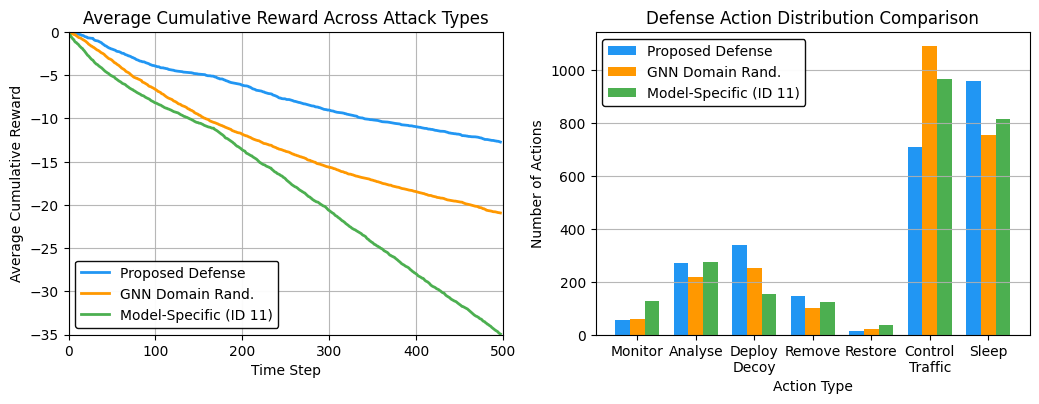

In [3]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# ============================================
# LEFT PLOT: Cumulative Reward
# ============================================
def load_step_rewards(path):
    """Loads all step reward sequences from a step_rewards.txt file."""
    step_rewards = []
    pattern = re.compile(r"Episode \d+ step_rewards: \[(.*?)\]")
    with open(path, "r") as f:
        for line in f:
            m = pattern.search(line)
            if m:
                rewards = np.fromstring(m.group(1), sep=",")
                step_rewards.append(rewards)
    return np.array(step_rewards)

def load_all_agents(base_dir):
    """Load all agents and return dict: {agent_name: step_rewards_array}."""
    agents = {
        "Proposed Defense": "step_rewards_ours.txt",
        "GNN Domain Rand.": "step_rewards_DR.txt", 
        "Model-Specific (ID 11)": "step_rewards_Rand.txt",
    }
    agent_data = {}
    for agent_name, filename in agents.items():
        file_path = os.path.join(base_dir, filename)
        rewards = load_step_rewards(file_path)
        agent_data[agent_name] = rewards
    return agent_data

def compute_average_per_agent(step_rewards):
    """Returns: average cumulative reward curve, shape (500,)"""
    cumulative = np.cumsum(step_rewards, axis=1)
    return cumulative.mean(axis=0)

# ============================================
# RIGHT PLOT: Action Distribution
# ============================================
def parse_actions_file(filepath):
    """Parse actions.txt and count action types."""
    action_counts = defaultdict(int)
    
    action_patterns = {
        'Monitor': re.compile(r'\[Monitor\]'),
        'Analyse': re.compile(r'\[Analyse'),
        'DeployDecoy': re.compile(r'\[DeployDecoy'),
        'Remove': re.compile(r'\[Remove'),
        'Restore': re.compile(r'\[Restore'),
        'BlockTrafficZone': re.compile(r'\[BlockTrafficZone\]'),
        'AllowTrafficZone': re.compile(r'\[AllowTrafficZone\]'),
        'Sleep': re.compile(r'\[Sleep\]')
    }
    
    with open(filepath, 'r') as f:
        content = f.read()
        
        for action_type, pattern in action_patterns.items():
            count = len(pattern.findall(content))
            action_counts[action_type] = count
    
    # Combine traffic control actions
    action_counts['Control Traffic'] = action_counts.pop('BlockTrafficZone', 0) + \
                                        action_counts.pop('AllowTrafficZone', 0)
    
    return action_counts

# ============================================
# MAIN PLOTTING
# ============================================
BASE_DIR = "."

# Load reward data
agents = load_all_agents(BASE_DIR)
print("Loaded agents:", list(agents.keys()))

agent_avg_curves = {}
for agent, rewards in agents.items():
    agent_avg_curves[agent] = compute_average_per_agent(rewards)

# Load action data
defense_files = {
    "Proposed Defense": "actions_ours.txt",
    "GNN Domain Rand.": "actions_DR.txt", 
    "Model-Specific (ID 11)": "actions_Rand.txt",
}

action_categories = ['Monitor', 'Analyse', 'DeployDecoy', 'Remove', 'Restore', 'Control Traffic', 'Sleep']
action_categories_name = ['Monitor', 'Analyse', 'Deploy\nDecoy', 'Remove', 'Restore', 'Control\nTraffic', 'Sleep']

all_counts = {}
for label, filename in defense_files.items():
    try:
        counts = parse_actions_file(filename)
        all_counts[label] = counts
        print(f"Loaded {label}: {sum(counts.values())} total actions")
    except FileNotFoundError:
        print(f"WARNING: {filename} not found")

# Prepare action data
methods = list(all_counts.keys())
data_matrix = np.zeros((len(action_categories), len(methods)))

for j, method in enumerate(methods):
    for i, action in enumerate(action_categories):
        data_matrix[i, j] = all_counts[method].get(action, 0)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4))

# ============================================
# LEFT PLOT: Cumulative Reward
# ============================================
colors = ['#2196F3', '#FF9800', '#4CAF50']
for (agent_name, curve), color in zip(agent_avg_curves.items(), colors):
    ax1.plot(curve, label=agent_name, linewidth=2, color=color)

ax1.set_xlabel("Time Step")
ax1.set_xlim([0,500])
ax1.set_ylim([-35, 0])
ax1.set_ylabel("Average Cumulative Reward")
ax1.set_title("Average Cumulative Reward Across Attack Types")
leg1 = ax1.legend(edgecolor="black",framealpha=0.95)
ax1.grid(True, alpha=0.9)
# leg = plt.legend(edgecolor="black",framealpha=0.95)
leg1.get_frame().set_linewidth(1)
# ============================================
# RIGHT PLOT: Action Distribution
# ============================================
x = np.arange(len(action_categories))
width = 0.25

for i, method in enumerate(methods):
    offset = width * (i - len(methods)/2 + 0.5)
    ax2.bar(x + offset, data_matrix[:, i]/100, width, label=method, color=colors[i])

ax2.set_xlabel('Action Type')
ax2.set_ylabel('Number of Actions')
ax2.set_title('Defense Action Distribution Comparison')
ax2.set_xticks(x)
ax2.set_xticklabels(action_categories_name, rotation=0, ha='center')
leg2 = ax2.legend(edgecolor="black",framealpha=0.95)
ax2.grid(True, alpha=0.9, axis='y')
leg2.get_frame().set_linewidth(1)
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)  # Add extra space at bottom
plt.savefig('res3.jpg', dpi=180)
# plt.tight_layout()
plt.show()


Episode 0: attacker SleepSwitchFSRandom.SleepSwitchFSRandom
Episode 1: attacker SleepSwitchFSRandom.SleepSwitchFSRandom
Episode 2: attacker SleepSwitchFSRandom.SleepSwitchFSRandom
Episode 3: attacker SleepSwitchFSRandom.SleepSwitchFSRandom
Episode 4: attacker SleepSwitchFSRandom.SleepSwitchFSRandom
Episode 5: attacker SleepSwitchFSRandom.SleepSwitchFSRandom
Episode 6: attacker SleepSwitchFSRandom.SleepSwitchFSRandom
Episode 7: attacker SleepSwitchFSRandom.SleepSwitchFSRandom
Episode 8: attacker SleepSwitchFSRandom.SleepSwitchFSRandom
Episode 9: attacker SleepSwitchFSRandom.SleepSwitchFSRandom
Episode 10: attacker SleepSwitchFSRandom.SleepSwitchFSRandom
Episode 11: attacker SleepSwitchFSRandom.SleepSwitchFSRandom
Episode 12: attacker SleepSwitchFSRandom.SleepSwitchFSRandom
Episode 13: attacker SleepSwitchFSRandom.SleepSwitchFSRandom
Episode 14: attacker SleepSwitchFSRandom.SleepSwitchFSRandom
Episode 15: attacker SleepSwitchFSRandom.SleepSwitchFSRandom
Episode 16: attacker SleepSwitchFS

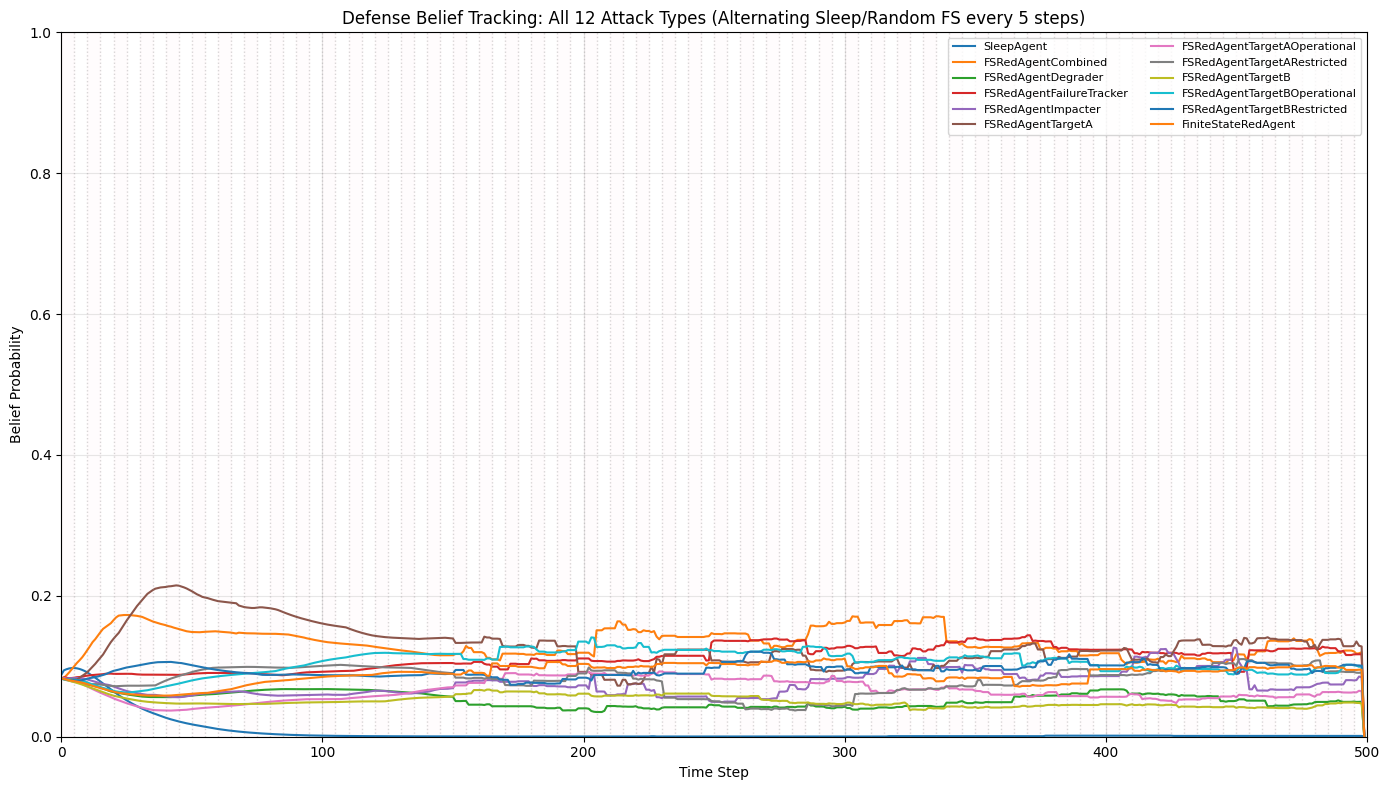

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import re
import ast

# Red-agent → ID mapping (12 attack types, excluding the switching agent)
red_agent_names = [
    "CybORG.Agents.SimpleAgents.ConstantAgent.SleepAgent",
    "FSRedAgentCombined.FSRedAgentCombined",
    "FSRedAgentDegrader.FSRedAgentDegrader",
    "FSRedAgentFailureTracker.FSRedAgentFailureTracker",
    "FSRedAgentImpacter.FSRedAgentImpacter",
    "FSRedAgentTargetA.FSRedAgentTargetA",
    "FSRedAgentTargetAOperational.FSRedAgentTargetAOperational",
    "FSRedAgentTargetARestricted.FSRedAgentTargetARestricted",
    "FSRedAgentTargetB.FSRedAgentTargetB",
    "FSRedAgentTargetBOperational.FSRedAgentTargetBOperational",
    "FSRedAgentTargetBRestricted.FSRedAgentTargetBRestricted",
    "CybORG.Agents.SimpleAgents.FiniteStateRedAgent.FiniteStateRedAgent",
]

attacker_name_to_id = {name: i for i, name in enumerate(red_agent_names)}

# Plot all 12 attack types
agent_ids = list(range(len(red_agent_names)))
agent_labels = red_agent_names


def read_belief_log(
    belief_file,
    num_episodes=100,
    episode_length=500,
    num_attackers=len(red_agent_names),
):
    beliefs = np.zeros(
        (num_episodes, episode_length, num_attackers),
        dtype=np.float32,
    )
    attack_ids = -np.ones(num_episodes, dtype=np.int32)

    class_pattern = re.compile(r"<class '([^']+)'>")

    with open(belief_file, "r") as f:
        lines = f.readlines()

    ep_idx = -1
    for line in lines:
        line = line.strip()

        # Skip headers
        if line.startswith("CybORG") or line.startswith("Author"):
            continue

        if line.startswith("Episode"):
            ep_idx += 1
            if ep_idx >= num_episodes:
                break

            raw = line.split("beliefs:", 1)[1].strip()

            # 🔧 FIX: replace <class 'X'> with 'X'
            sanitized = class_pattern.sub(r"'\1'", raw)

            try:
                ep_beliefs = ast.literal_eval(sanitized)
            except Exception as e:
                raise RuntimeError(
                    f"Failed parsing episode {ep_idx}\n"
                    f"Original: {raw[:200]}...\n"
                    f"Sanitized: {sanitized[:200]}..."
                ) from e

            for entry in ep_beliefs:
                t = entry["t"]
                belief_vec = np.asarray(entry["belief"], dtype=np.float32)

                if t >= episode_length:
                    continue

                beliefs[ep_idx, t, :] = belief_vec

                if attack_ids[ep_idx] == -1:
                    attacker_name = "SleepSwitchFSRandom.SleepSwitchFSRandom"
                    attack_ids[ep_idx] = attacker_name_to_id.get(attacker_name, -1)  # Not in the 12, so -1 or handle differently
            print(f"Episode {ep_idx}: attacker {attacker_name}")


    return beliefs, attack_ids

beliefs, attack_ids = read_belief_log("belief_log.txt")
print(f"Loaded beliefs shape: {beliefs.shape}")

if beliefs.shape[0] > 0:
    mean_belief = beliefs.mean(axis=0)  # [T, A] - average across episodes

    # Plot
    plt.figure(figsize=(14, 8))

    for agent_id, label in zip(agent_ids, agent_labels):
        plt.plot(
            mean_belief[:, agent_id],
            linewidth=1.5,
            label=label.split('.')[-1]  # Shorten label to last part
        )

    # Add vertical lines at switching points (every 5 steps)
    switch_points = list(range(5, 500, 5))
    for sp in switch_points:
        plt.axvline(x=sp, color='gray', linestyle=':', alpha=0.3, linewidth=1)

    # Shade background by period (alternating 5-step blocks)
    colors = ['#ffebee', '#e3f2fd']
    for i in range(0, 100, 2):  # 100 5-step periods
        start = i * 5
        end = start + 5
        if end <= 500:
            plt.axvspan(start, end, alpha=0.1, color=colors[i % 2])

    plt.xlabel("Time Step")
    plt.ylabel("Belief Probability")
    plt.title("Defense Belief Tracking: All 12 Attack Types (Alternating Sleep/Random FS every 5 steps)")
    plt.legend(loc='upper right', fontsize=8, ncol=2)
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 500])
    plt.ylim([0, 1])
    plt.tight_layout()
    plt.show()
else:
    print("No beliefs to plot")
